# 1.🍽️ Zomato Restaurant Data Analysis
### Exploring restaurant trends, ratings, and customer preferences using Python

**Tools used:** Pandas, NumPy, Matplotlib, Seaborn  
**Dataset:** Zomato restaurant listings (Bangalore)  
**Goal:** Uncover patterns in ratings, pricing, and ordering behavior to help understand customer preferences

## 2. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load The Dataset

In [9]:
df = pd.read_csv('Zomato data .csv')
df.head()


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## 4. Initial Data Exploration
checking shape, data types , and structure of the dataset

In [11]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


(148, 7)

In [12]:
df['rate']. unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', '2.9/5', '3.5/5', '2.6/5', '3.8 /5', '3.4/5'],
      dtype=object)

## 4. Data Clening - Fixing the 'rate column'
The 'rate' column was stored as text (e.g , "4.1/5"). This funciton extracts the numeric rating and converts it to a float for analysis. 

In [14]:
def handle_rate(value):
    value = str(value).split('/')[0]
    value = value.strip()
    return float(value)
df['rate'] = df['rate'].apply(handle_rate)

In [15]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


## 5. Analysis & Insights
Now that the data is clean , let's answer key business questions about restaurant trends, ratings, and customer preferences.

### Q1: Which type of restaurant is most common?

In [19]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

### 📊 Visualization: Most Common Restaurant Type

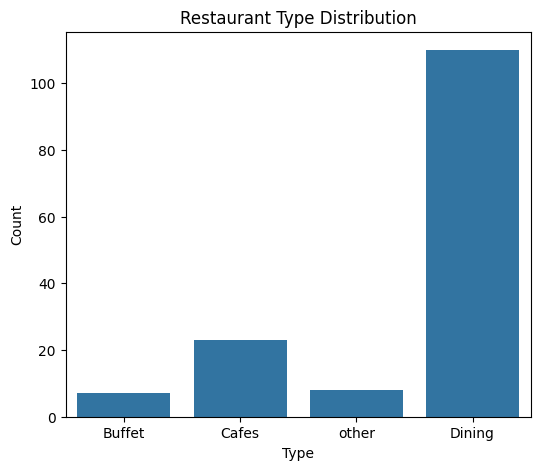

In [24]:
plt.figure(figsize=(6,5))
sns.countplot(x='listed_in(type)' ,data= df)
plt.title('Restaurant Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

**Insight:** Dining restaurants are overwhelmingly the most common type, visually confirming what we saw in the value_counts() table.

 ## Q 2 : Which restaurant got the highest votes?

In [26]:
df.loc[df['votes'].idxmax()]

name                           Empire Restaurant
online_order                                 Yes
book_table                                    No
rate                                         4.4
votes                                       4884
approx_cost(for two people)                  750
listed_in(type)                            other
Name: 38, dtype: object

### 📊 Visualization: Top 10 Restaurants by Votes

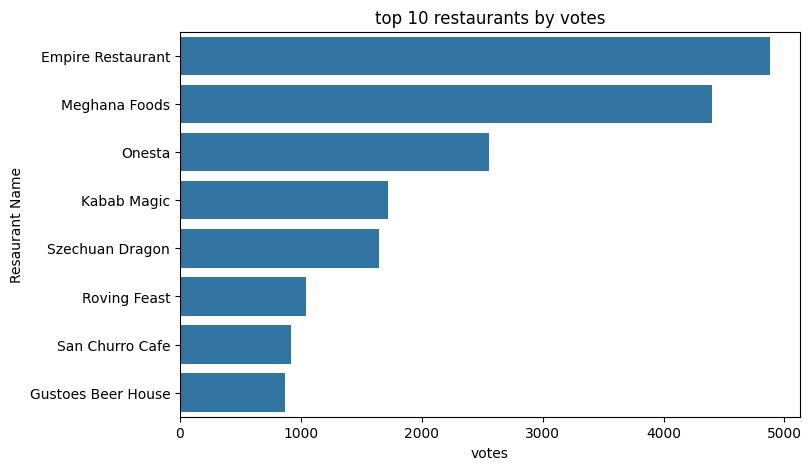

In [27]:
top_votes = df.nlargest(10,'votes')
plt.figure(figsize=(8,5))
sns.barplot(x='votes',y='name',data=top_votes)
plt.title('top 10 restaurants by votes')
plt.xlabel('votes')
plt.ylabel('Resaurant Name')
plt.show()

**Insight:** Empire Restaurant leads significantly with 4,884 votes — nearly 1.5x more than the second-highest restaurant, showing exceptional customer engagement.

### Q3: Do restaurants with online ordering have better ratings?

In [29]:
avg_rating_by_order = df.groupby('online_order')['rate'].mean()
print(avg_rating_by_order)

online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64


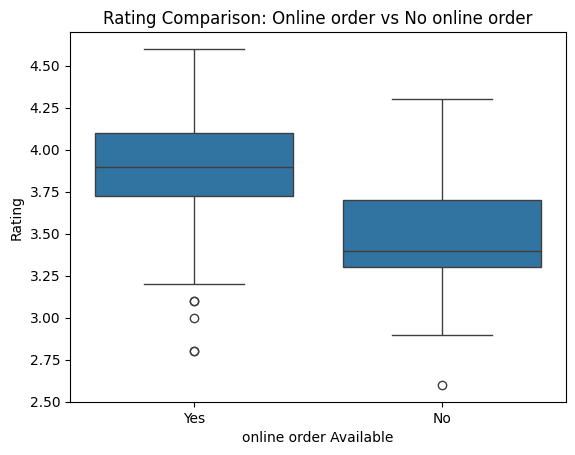

In [30]:
sns.boxplot(x='online_order',y='rate',data=df)
plt.title('Rating Comparison: Online order vs No online order')
plt.xlabel('online order Available')
plt.ylabel('Rating')
plt.show()

**Insight:** The boxplot visually confirms that restaurants offering online ordering tend to have higher typical ratings than those without it.

### Q4: What is the most common approximate cost for two people?

In [32]:
df['approx_cost(for two people)'].value_counts().head(10)

approx_cost(for two people)
300    23
150    16
200    16
400    15
500    14
600    13
800    12
250     6
100     6
450     6
Name: count, dtype: int64

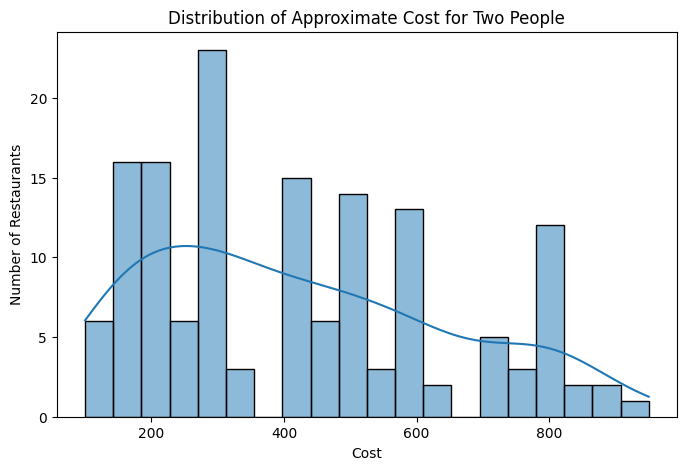

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['approx_cost(for two people)'],bins=20,kde=True)
plt.title('Distribution of Approximate Cost for Two People')
plt.xlabel('Cost')
plt.ylabel('Number of Restaurants')
plt.show()

**Insight:** The cost distribution is right-skewed, with most restaurants clustering around ₹300 for two people, and a smaller number of premium restaurants extending toward higher price points.

### Q5: Does table booking availability affect restaurant ratings?

In [35]:
avg_rating_by_booking = df.groupby('book_table')['rate'].mean()
print(avg_rating_by_booking)

book_table
No     3.601429
Yes    4.187500
Name: rate, dtype: float64


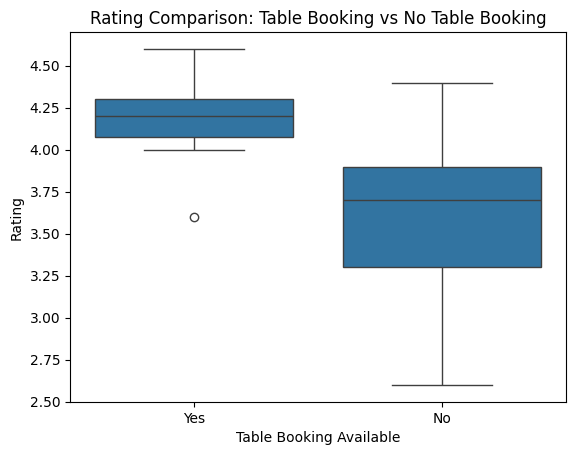

In [36]:
sns.boxplot(x='book_table', y='rate', data=df)
plt.title('Rating Comparison: Table Booking vs No Table Booking')
plt.xlabel('Table Booking Available')
plt.ylabel('Rating')
plt.show()

**Insight:** Restaurants offering table booking have significantly higher average ratings (4.19) compared to those without (3.60), suggesting table booking is associated with more premium or well-managed restaurants.

## 📌 Key Insights

1. **Restaurant Types:** Dining restaurants dominate the market (110 out of 148, ~74%), far more common than Cafes, Buffet, or other types.

2. **Top Performer:** Empire Restaurant leads with 4,884 votes and a 4.4 rating — nearly 1.5x more engagement than any other restaurant.

3. **Online Ordering Impact:** Restaurants offering online ordering have higher average ratings (3.86) compared to those without (3.49).

4. **Pricing Sweet Spot:** ₹300 for two people is the most common price point (23 restaurants), suggesting this is the price range customers find most appealing.

5. **Table Booking Impact:** Restaurants with table booking available have significantly higher ratings (4.19) vs those without (3.60) — the strongest relationship found in this analysis.

## 🛠️ Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn

## 🔗 Connect
This project is part of my Data Analyst portfolio journey.